# Implementación del QAE en átomos neutros

En este cuaderno busco intentar realizar el estudio de un portfolio de dos T-Bills en Bloqade de QuEra.

Comenzamos importando los paquetes necesarios para abordar el problema:

In [4]:
using Bloqade #Átomos neutros de QuEra
using Bloqade.CairoMakie #Para gráficar
using LinearAlgebra #Para cálculos entre estados
using OrdinaryDiffEq #Paquete para resolver la ecuación de Schrödinger
using Yao #Para trabajar con los estados de qubits.
using Random #Para simulaciones de Monte Carlo

El primer paso es definir la geometría del problema. Usaremos tres qubits para tratar el problema. Dos de ellos representarán los activos, mientras que el qubit del medio servirá para determinar los casos en los que ambos se encuentran en el estado Rydberg. Nos referiremos a este último como "oráculo", ya que es el que indicará cuándo ambos estados se encuentran en pérdida. 

## Definiciones

Definimos una distancia interatómica de $7.0$  $\mu m$, de manera que pueda ocurrir el bloqueo Rydberg.

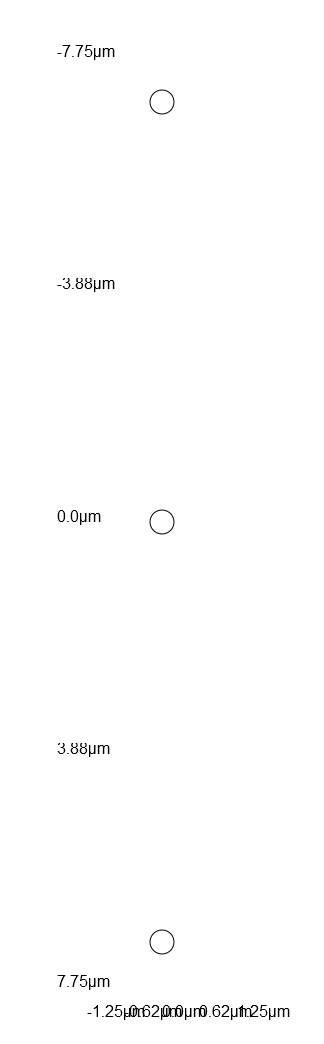

In [5]:
atomos = AtomList([(0.0, 7.0), (0.0, -7.0), (0.0, 0.0)]) #Generamos la geometría del problema

Una vez definidos la geometría del problema podemos encargarnos de los valores de la frecuencia de rabi $\Omega$ y del detuning $\Delta_i$. El valor que asignamos a la frecuencia de Rabi será $\Omega = 4.0 \hspace{0.1 cm} rad/μs$. El valor que daremos al detuning será el máximo que permite el hardware de QuEra, ya que buscamos bloquear átomos que lo sientan mientras configuramos el sistema. Además, definimos un tiempo para que los láseres lleguen al estado necesario, denominado como $t_{rampa}$.

In [6]:
Ω_max = 4.0 #Frecuencia de Rabi.  rad/ μs
Δ_mask = 125.0 #Valor del detuning. rad/μs
t_rampa = 0.02; #Tiempo de configuración. μs

## Data loading

Una vez definidos la geometría del problema y los parámetros necesarios para preparar los estados, podemos comenzar a plantear el problema a estudiar. Vamos a asignar una probabilidad de pérdida a cada uno de nuestros activos. El activo A tendrá un $20\%$ de probabilidad, mientras que el activo B tendrá un $30\%$. 

Para conseguir implementar esto en nuestro problema físico, debemos dejar actuar sobre cada qubit el láser con frecuencia Ω. Esto lo conseguimos desactivando el detuning sobre dicho átomo. Para conseguir que el qubit objetivo acabe con una probabilidad dada, el láser ha de actuar sobre él un cierto tiempo. (VOLVER PARA DAR MÁS DETALLES). Además, para que el proceso sea viable, añadimos gaps de 50 nanosegundos cada vez que cambiamos el átomo que manipulamos. De esta manera, teniendo en cuenta el área bajo el trapecio, los valores son:

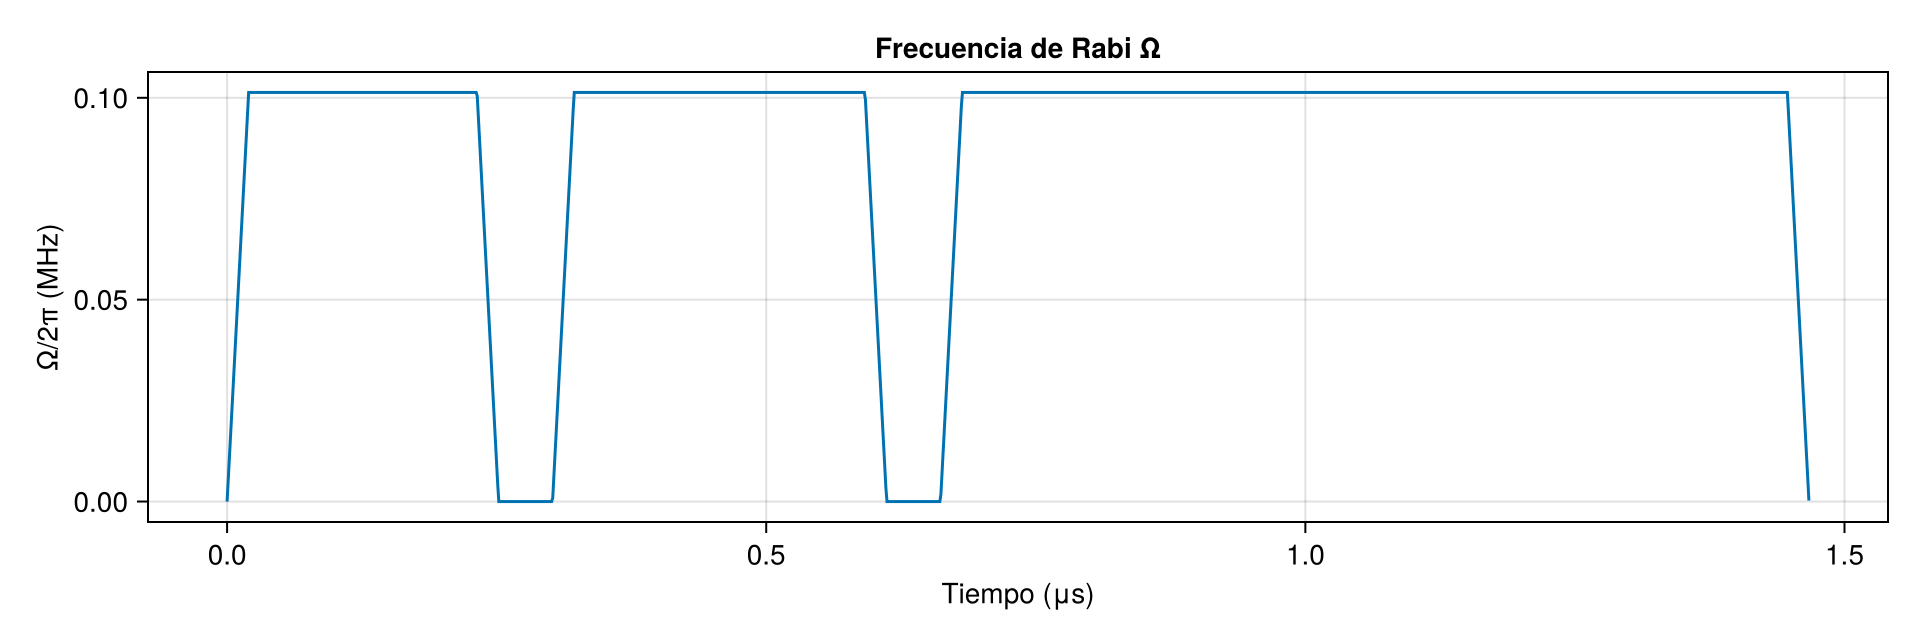

In [7]:
#Construimos los tiempos para las mesetas.
t_meseta_A = (0.9273 / Ω_max) - t_rampa 
t_meseta_B = (1.1593 / Ω_max) - t_rampa
t_gap= 0.05
t_meseta_O = (π / Ω_max) - t_rampa

#Construimos el resto de tiempos para el pulso.
t0 = 0.0
t1 = t0 + t_rampa; t2 = t1 + t_meseta_A; t3 = t2 + t_rampa #Pulso A
t4 = t3 + t_gap #Gap entre A y B
t5 = t4 + t_rampa; t6 = t5 + t_meseta_B; t7 = t6 + t_rampa #Pulso B
t8 = t7 + t_gap #Gap entre B y O
t9 = t8 + t_rampa; t10 = t9 + t_meseta_O; t11 = t10 + t_rampa #Pulso O

clocks = [t0, t1, t2, t3, t4, t5, t6, t7, t8, t9, t10, t11]
tiempo_total = clocks[end] #Tiempo total del pulso.

#Construimos los valores para el láser de Ω.

Ω_values = [0.0, Ω_max, Ω_max, 0.0, 0.0, Ω_max, Ω_max, 0.0, 0.0, Ω_max, Ω_max, 0.0]

Ω_waveform = piecewise_linear(clocks = clocks, values = Ω_values)

#Graficamos la forma del pulso para la frecuencia de Rabi
fig = Figure(size = (960,320))
ax1 = Axis(fig[1, 1], xlabel = "Tiempo (μs)", ylabel = "Ω/2π (MHz)", title = "Frecuencia de Rabi Ω")
Bloqade.plot!(ax1, Ω_waveform / (2π))
fig

Definimos del mismo modo el valor para el detuning Δ y lo representamos gráficamente:

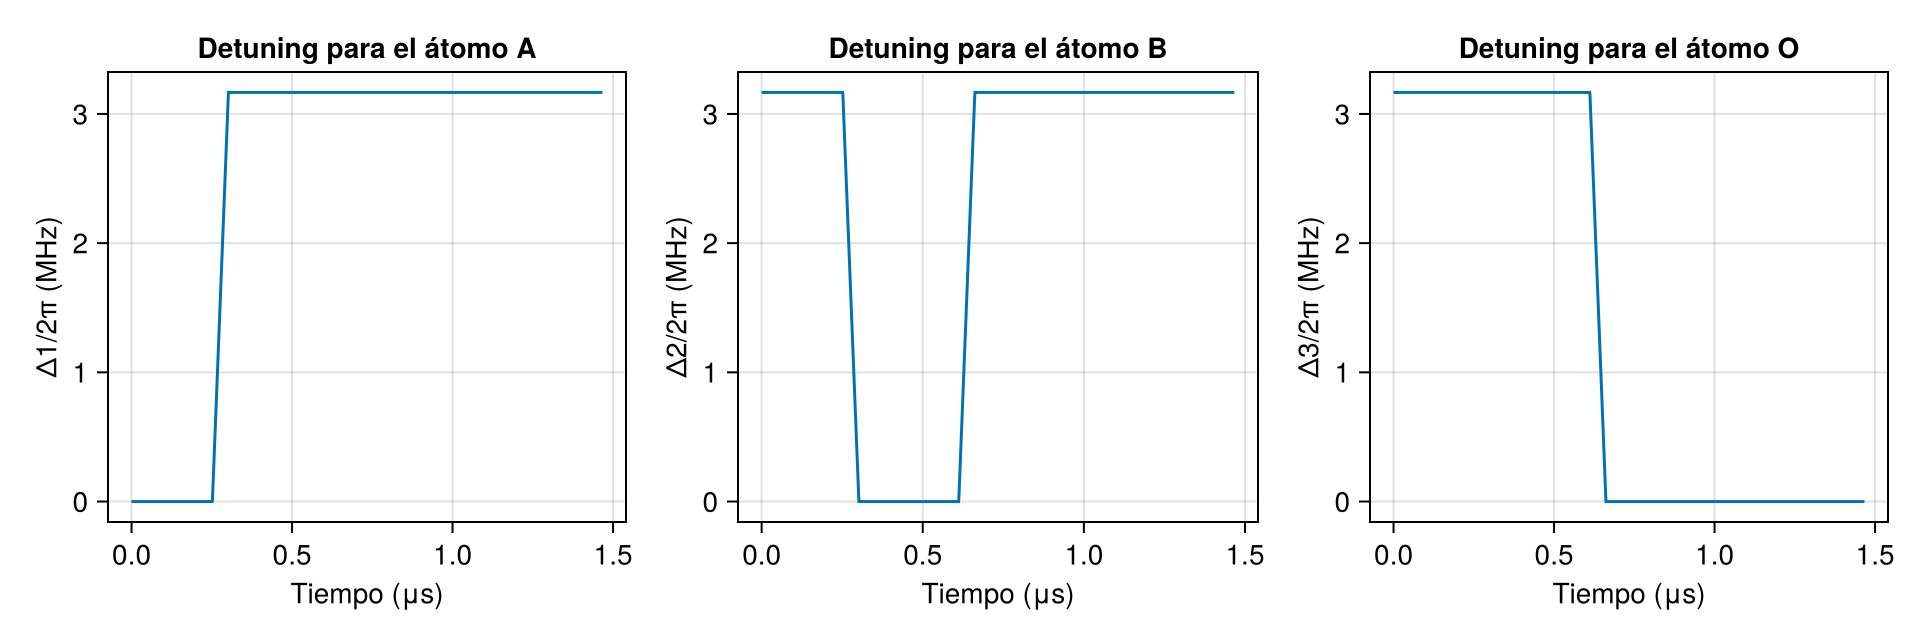

In [8]:
#Definimos los valores para los pulsos de detuning que actúan sobre cada átomo.
valores_Δ1 = [0.0, 0.0, 0.0, 0.0, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask]
Δ_1 = piecewise_linear(clocks = clocks, values = valores_Δ1)

valores_Δ2 = [Δ_mask, Δ_mask, Δ_mask, Δ_mask, 0.0, 0.0, 0.0, 0.0, Δ_mask, Δ_mask, Δ_mask, Δ_mask]
Δ_2 = piecewise_linear(clocks = clocks, values = valores_Δ2)

valores_Δ3 = [Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, Δ_mask, 0.0, 0.0, 0.0, 0.0]
Δ_3 = piecewise_linear(clocks = clocks, values = valores_Δ3)

#Representamos gráficamente los pulsos creados.
fig = Figure(size = (960,320))
ax1 = Axis(fig[1, 1], xlabel = "Tiempo (μs)", ylabel = "Δ1/2π (MHz)", title = "Detuning para el átomo A")
Bloqade.plot!(ax1, Δ_1 / (2π))
ax2 = Axis(fig[1,2], xlabel = "Tiempo (μs)", ylabel = "Δ2/2π (MHz)", title = "Detuning para el átomo B")
Bloqade.plot!(ax2, Δ_2 / (2π))
ax3 = Axis(fig[1,3], xlabel = "Tiempo (μs)", ylabel = "Δ3/2π (MHz)", title = "Detuning para el átomo O")
Bloqade.plot!(ax3, Δ_3 / (2π))
fig

Una vez definidos los pulsos, podemos pasar a generar el hamiltoniano del sistema en Bloqade.

In [9]:
H = rydberg_h(atomos; Ω = Ω_waveform, Δ = [Δ_1, Δ_2, Δ_3]) #Generamos el hamiltoniano del sistema

nqubits: 3
+
├─ [+] ∑ 2π ⋅ 8.627e5.0/|x_i-x_j|^6 n_i n_j
├─ [+] Ω(t) ⋅ ∑ σ^x_i
└─ [-] ∑ Δ_i ⋅ n_i


Inicializamos un registro con los tres qubits en el estado fundamental, después, definimos el problema a resolver y utilizamos Vern8() para resolver la evolución del sistema. Una vez terminada, el estado resultante debería contener la información que buscábamos. 

In [10]:
#Definimos el estado |000>.
reg = zero_state(3) 

#Definimos el problema.
prob = SchrodingerProblem(reg, tiempo_total, H)

#Resolvemos la evolución del estado inicial.
integrator = init(prob, Vern8())
solve!(integrator);

Una vez poseemos el estado final, comprobamos que las probabilidades del estado que acabamos de preparar son las correctas:

In [11]:
prob_A = rydberg_density(reg,1)
prob_B = rydberg_density(reg,2)
prob_O= rydberg_density(reg,3)

println("--- Resultados de la Preparación del Estado ---")
println("Probabilidad de Default Activo A (Objetivo 20%): ", round(prob_A * 100, digits=2), "%")
println("Probabilidad de Default Activo B (Objetivo 30%): ", round(prob_B * 100, digits=2), "%")
println("Estado de la Ancilla (Debería ser 56%): ", round(prob_O * 100, digits=2), "%")

--- Resultados de la Preparación del Estado ---
Probabilidad de Default Activo A (Objetivo 20%): 22.31%
Probabilidad de Default Activo B (Objetivo 30%): 33.29%
Estado de la Ancilla (Debería ser 56%): 52.37%


## Iterative Quantum Amplitude Estimation

En este apartado definimos una función que implementa el IQAE actuando sobre el estado que hemos preparado anteriormente.

In [79]:
function IQAE(k::Int, reg)
    """ IQAE recibe un entero k de iteraciones y un registro que contiene el estado inicial del sistema a iterar """
    
    psi_0 = copy(reg.state)
    estado_actual = copy(reg.state)

    #Bucle de Grover (k iteraciones):
    for _ in 1:k
        #Aquí cambiamos el signo de los estados que tienen el oráculo en |1>.
        #Con Yao.jl, el oráculo es 1 en los índices 5 a 8 del registro.
        estado_actual[5:8] .= -estado_actual[5:8]

        #Ahora aplicamos el Operador de Difusión: Reglexión exacta sobre el estado inicial:
        solapamiento = dot(psi_0, estado_actual) #Producto interno
        estado_actual .= 2 * solapamiento .* psi_0 .- estado_actual
    end

    reg_final = ArrayReg(estado_actual)
    prob = rydberg_density(reg_final, 3) #Medimos el oráculo
    return prob
end
        
function algoritmo_IQAE(reg)
    println("=== INICIANDO ITERATIVE QUANTUM AMPLITUDE ESTIMATION ===")
    #Calculamos la probabilidad sin ruido.
    p_real_teorico = IQAE(0, reg)
    println("Probabilidad teórica exacta: ", round(p_real_teorico * 100, digits = 4), "%")
    
    #Creamos los valores para las llamadas al oráculo.
    k_valores = [0, 1, 2, 4, 8, 16, 32, 64, 128]
    N_shots = 100 #Medidas por circuito
    
    #Registros del Benchmark:
    probabilidades = Float64[]
    vector_errores = Float64[]
    llamadas_oraculo = Int[]
    coste_acumulado = 0

    #Análisis de ángulos para MLE:
    posibles_thetas = range(0, stop = π/2, length = 100000)

    for (idx_max, k_eval) in enumerate(k_valores)
        # Simulación del Hardware
        P_k_exc = IQAE(k_eval, reg)
        exitos = sum(rand() < P_k_exc for _ in 1:N_shots)
        push!(probabilidades, exitos / N_shots)

        #Guardamos cuál es el coste total de las simulaciones, sumando el número de medidas por las llamadas
        # al oráculo a las llamadas anteriores.

        coste_acumulado += N_shots * (2*k_eval + 1)

        #Buscamos el mejor ángulo por MLE:
        mejor_theta = 0.0
        menor_error = Inf

        for theta_test in posibles_thetas
            error_total = 0.0
            for i in 1:idx_max
                k_actual = k_valores[i]
                p_teo = sin((2*k_actual + 1) * theta_test)^2
                error_total += abs(probabilidades[i] - p_teo)
            end
            if error_total < menor_error
                menor_error = error_total
                mejor_theta = theta_test
            end
        end

        #Calculamos el error total para la evaluación k_eval:

        p_est_k = sin(mejor_theta)^2
        err_abs = abs(p_est_k - p_real_teorico)
        err_seguro = max(err_abs, 1e-6) #Nos aseguramos de que ningún valor sea exactamente cero.

        push!(vector_errores, err_seguro)
        push!(llamadas_oraculo, coste_acumulado)
    end

    println("---------------------------------------")
    return llamadas_oraculo, vector_errores, p_real_teorico
end   
        
    


llamadas, errores, p = algoritmo_IQAE(reg);

=== INICIANDO ITERATIVE QUANTUM AMPLITUDE ESTIMATION ===
Probabilidad teórica exacta: 52.3661%
---------------------------------------


## Simulación de Monte Carlo

En este apartado buscamos estudiar el mismo problema haciendo uso de métodos de Monte Carlo con el fin de comparar ambos métodos y demostrar el sped-up cuadrático que supone utilizar algoritmos cuánticos como IQAE.

Partimos definiendo la probabilidad que buscamos estimar como el resultado obtenido por el IQAE.

In [80]:
p_real = p;

Definimos a continuación una función que ejecute la estimación de dicha probabilidad $p$ haciendo uso de Monte Carlo con un número de muestras $M$ y que devuelva el error absoluto resultante.

In [83]:
function estimacion_MC(p, M)
    #Simulamos M tiradas. Si rand() < p, contamos un éxito.
    exitos = sum(rand() < p for _ in 1:M)
    p_estimada = exitos / M 
    return abs(p_estimada - p)
end

#Evaluamos el error para diferentes tamaños muestrales
M =[10^i for i in 2:5]
errores_MC = Float64[]

for m in M
    error_promedio = sum(estimacion_MC(p_real,m) for _ in 1:100) / 100
    push!(errores_MC, error_promedio)
end

Mt = 10 .^ range(2, stop = 5, length = 100)

#Matemáticamente, Monte Carlo escala como 1/sqrt(M)
error_teo_MC = [sqrt(p_real * (1-p_real) / m) for m in Mt] 


#Realizamos el estudio de los errores obtenidos por IQAE:
#El errore de IQAE escala asintóticamente como O(1/M)
#Primero ajustamos la constante inicial para que parta del mismo error simulado:
c_IQAE = errores[1] * llamadas[1]
err_teo_IQAE = [c_IQAE / m for m in Mt];

Una vez disponemos de los errores tanto de la simulación de Monte Carlo como los errores del IQAE, podemos representar gráficamente cómo estos evolucionan con el tamaño.

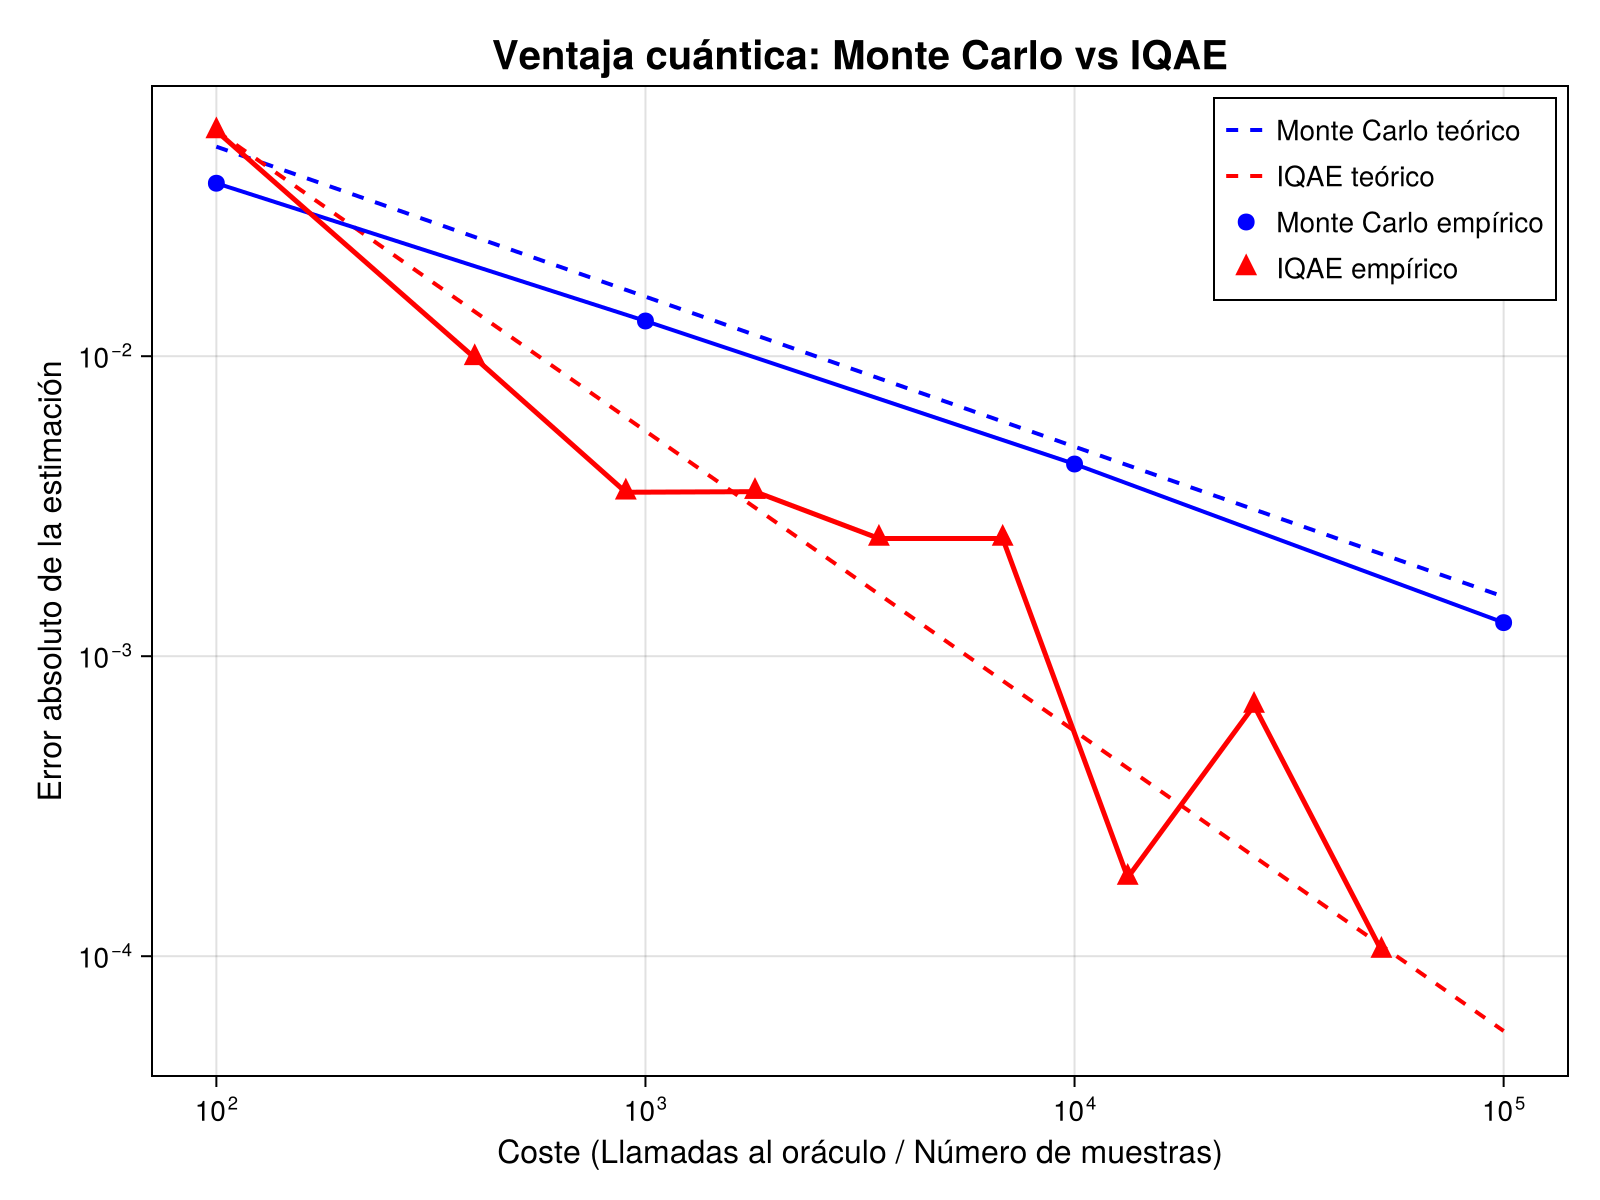

In [84]:
fig = Figure(size = (800,600))
ax = Axis(fig[1, 1],
    xscale = log10, yscale = log10, #Escala logarítmica
    xlabel = "Coste (Llamadas al oráculo / Número de muestras)",
    ylabel = "Error absoluto de la estimación",
    title = "Ventaja cuántica: Monte Carlo vs IQAE",
    titlesize = 20,
    xlabelsize = 16, ylabelsize = 16)

#--- Teóricas (líneas a trazos sin puntos)
lines!(ax, Mt, error_teo_MC, color = :blue, linewidth = 2, linestyle = :dash, label = "Monte Carlo teórico")
lines!(ax, Mt, err_teo_IQAE, color = :red, linewidth = 2, linestyle = :dash, label = "IQAE teórico")

#--- Monte Carlo empírico
lines!(ax, M, errores_MC, color = :blue, linewidth = 2)
scatter!(ax, M, errores_MC, color = :blue, markersize = 12, label = "Monte Carlo empírico")

#--- IQAE empírico
lines!(ax, llamadas, errores, color = :red, linewidth = 2.5)
scatter!(ax, llamadas, errores, color = :red, marker = :utriangle, markersize = 15, label = "IQAE empírico")


axislegend(ax, position = :rt, labelsize = 14)

fig

## Conclusiones y frentes abiertos.

Hemos demostrado cómo para un caso muy sencillo como el de dos T-Bills, utilizar átomos neutros y algoritmos cuánticos resulta más eficiente que métodos clásicos a la hora de determinar valores como el VaR. Sin embargo, esto es solo la punta del iceberg. Ahora podemos seguir estudiando cómo escalar el problema para llevarlo a casos más prácticos y cómo optimizar la metodología para reducir coste computacional.

Para $n$ activos se necesitan $n + 1$ qubits para estudiar este tipo de sistemas. Escalar el problema no es complicado, la dificultad surge a la hora de la preparación de estados:
*   Ahora mismo, la gráfica depende bastante de cada vez que se ejecuta el código. Podríamos representar gráficamente los valores promedio resultantes para los errores.

*   Para el caso en el que tenemos $n$ T-Bills independientes con misma probabilidad de pérdida, el tiempo de preparación y el coste computacional escala con 
    $O(1)$, solo necesitamos un pulso global para preparar los estados.
    
*   Si los $n$  T-Bills independientes tienen diferentes probabilidades de pérdida, se puede estudiar la manera de preparar todos los estados de manera simultánea
    mediante pulsos con moduladores (detuning). Optimizar el tiempo de preparación de los estados puede ser interesante a la hora de buscar escalar el problema.

*   Introducir correlación entre activos. Este es un objetivo mucho más ambicioso porque se debería cambiar el enfoque del sistema. Trataríamos de encontrar una    configuración que representase de manera fiel las correlaciones entre activos mediante un barrido adiabático y después estudiar dicho estado. Esto se consigue modificando la posición de los átomos con el tiempo, para introducir superposición de estados mediante el bloqueo Rydberg. No lo considero muy viable. Puede ser una de las conclusiones del trabajo.

## Sobre la memoria.
Propongo un esquema para la memoria del trabajo. La extensión debe de ser de 20 páginas contando índice, introducción, conclusiones y bibliografía. Supongamos que disponemos de unas 17 páginas para desarrollar el tema. Un primer esquema a esta altura puede ser:
*  **Índice** (1 página)
*  **Introducción** (1 página) Resumen del problema, el objetivo y los algoritmos utilizados.
*  **Computación cuántica en átomos neutros:**  Hablar de las bases físicas y su interés. Introducir QuEra, Julia, mencionar Aquilla. *(2-3 páginas)*
*  **Analógico:** Introducir el hamiltoniano, explicar los pulsos de Rabi y Detuning. Explicar el fenómeno del bloqueo Rydberg. *(2-3 páginas)*
*  **Credit Risk Analysis:** Mostrar el incentivo, cómo algoritmos cuánticos consiguen el sped-up cuadrático frente Monte Carlo. Presentar el problema de los T-Bills. *(1 página)*
*  **Preparación de estados:** Cómo se prepara el estado objetivo, tanto a nivel físico (haciendo enfásis en las limitaciones de hardware) como computacional (demostrando consistencia con el hardware). *(3 páginas)*
*  **Iterative Quantum Amplitude Estimation:** Introducir el algoritmo cuántico que utilizamos y su implementación en Julia. *(1-2 páginas)*
*  **Método de Monte Carlo:** Introducir la metodología actual e implementarla en Julia *(1 página)*
*  **Comparación y demostración del sped-up cuadrático:** Evaluar el problema y realizar la comparación de la estimación del error absoluto mediante Monte Carlo e IQAE *(2 páginas)*
*  **Conclusiones:** hablar sobre los resultados y posibles frentes donde seguir utilizando esta ventaja *(1 página)*
*  **Bibliografía** *(1 página)*

Son unas 18 páginas, de manera que haya margen para explayarse en alguno de los apartados.

  
